# Planar Rover Observability

This notebook simulates planar rover motion embedded in full SE(3),
compares dense and sparse observability reductions, runs sliding-window
analysis, and contrasts full SE(3) planar degeneracy with reduced SE(2)
and synthetic 3D excitation.

In [1]:
from pathlib import Path
import sys, time
ROOT = Path.cwd()
for candidate in (ROOT, *ROOT.parents):
    if (candidate / "src" / "calib_observability").exists():
        ROOT = candidate
        break
sys.path.insert(0, str(ROOT / "src"))
OUT = ROOT / "outputs" / "planar_rover"
OUT.mkdir(parents=True, exist_ok=True)

import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse

from calib_observability.backend import estimate_poses_dummy
from calib_observability.factor_observability import SUPPORTED_CALIBRATION_VARIABLES, sliding_window_factor_diagnostics
from calib_observability.linalg import numerical_rank_dense
from calib_observability.lie_se2 import se2_exp
from calib_observability.lie_se3 import se3_log
from calib_observability.observability import *
from calib_observability.plotting import save_sparsity_plot, save_singular_values_plot
from calib_observability.simulation import PlanarRoverConfig, simulate_planar_rover
from calib_observability.types import JacobianOptions

rng = np.random.default_rng(321)

def rank_dense(M, tol=1e-7):
    return numerical_rank_dense(M.toarray() if sparse.issparse(M) else M, tolerance=tol)

## Jacobian Method Configuration

`analytic` uses closed-form factor Jacobians in assembly. `finite_difference` uses central left-perturbation finite differences as a numerical reference. `analytic_checked` computes both, assembles the analytic blocks, and stores per-block comparison diagnostics in `JacobianBundle.metadata`.

The default notebook tolerance is slightly looser than the package default for absolute error because the rectangular trajectory has piecewise velocity changes; temporal-offset finite differences can straddle those phase boundaries.


In [28]:
# JACOBIAN_METHOD = "analytic_checked"
JACOBIAN_METHOD = "analytic"
JACOBIAN_OPTIONS = JacobianOptions(
    method=JACOBIAN_METHOD,
    finite_difference_epsilon=1e-7,
    check_atol=5e-6,  # rectangle phase boundaries can make temporal-offset checks slightly less smooth
    check_rtol=1e-5,
    raise_on_check_failure=True,
)
print(JACOBIAN_OPTIONS)


JacobianOptions(method='analytic', finite_difference_epsilon=1e-07, check_atol=5e-06, check_rtol=1e-05, raise_on_check_failure=True)


## 1. Simulation Configuration

In [29]:
cfg = PlanarRoverConfig(imu_rate_hz=100.0, lidar_rate_hz=5.0, total_laps=1, random_seed=21)
ds = simulate_planar_rover(cfg, mode="one_rectangle")
print(cfg)
assert ds.lidar.measurements.shape[0] > 10

PlanarRoverConfig(rectangle_width=8.0, rectangle_height=5.0, straight_speed=1.0, turn_duration=1.5, acceleration_duration=0.8, total_laps=1, imu_rate_hz=100.0, lidar_rate_hz=5.0, tau_I_true=0.01, tau_L_true=-0.02, gyro_bias_true=(0.005, -0.003, 0.01), T_B_I_true=(0.01, -0.02, 0.03, 0.12, 0.0, 0.08), T_B_L_true=(0.0, 0.0, 0.04, 0.35, 0.05, 0.12), gyro_noise_std=0.002, accel_noise_std=0.03, lidar_pose_noise_std=(0.005, 0.005, 0.005, 0.02, 0.02, 0.02), random_seed=21, mode='one_rectangle')


## 2. Rectangular Rover Trajectory Plot

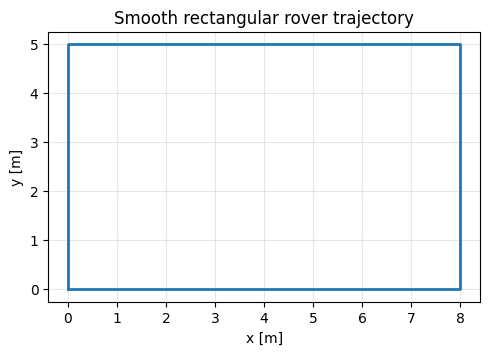

In [30]:
t, xyz, rpy = ds.trajectory.sample(500)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(xyz[:, 0], xyz[:, 1], lw=2)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_title("Smooth rectangular rover trajectory") 
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "trajectory_xy.png", dpi=160)
plt.show()
plt.close(fig)

## 3. Position, Yaw, Velocity, Yaw-Rate, And Acceleration

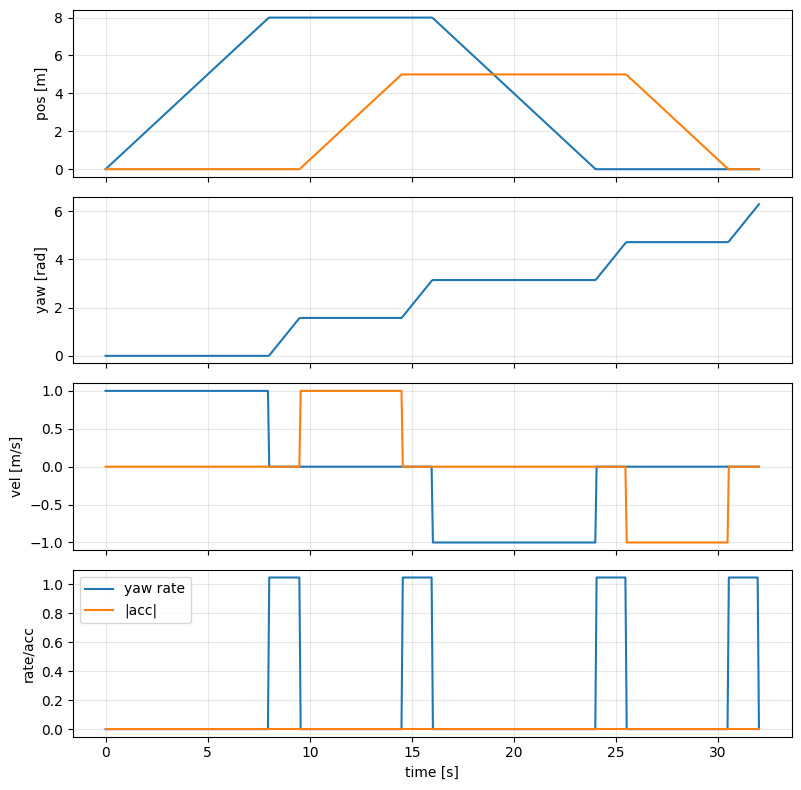

In [31]:
vel = np.vstack([ds.trajectory.velocity_at(float(ti)) for ti in t])
acc = np.vstack([ds.trajectory.acceleration_at(float(ti)) for ti in t])
yaw_rate = np.array([ds.trajectory.yaw_rate_at(float(ti)) for ti in t])
fig, axs = plt.subplots(4, 1, figsize=(8, 8), sharex=True)
axs[0].plot(t, xyz[:, :2]); axs[0].set_ylabel("pos [m]")
axs[1].plot(t, rpy[:, 2]); axs[1].set_ylabel("yaw [rad]")
axs[2].plot(t, vel[:, :2]); axs[2].set_ylabel("vel [m/s]")
axs[3].plot(t, yaw_rate, label="yaw rate"); axs[3].plot(t, np.linalg.norm(acc[:, :2], axis=1), label="|acc|"); axs[3].legend(); axs[3].set_ylabel("rate/acc")
axs[3].set_xlabel("time [s]")
for ax in axs:
    ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "trajectory_timeseries.png", dpi=160)
plt.show()
plt.close(fig)

## 4. IMU And LiDAR Timestamp Visualization

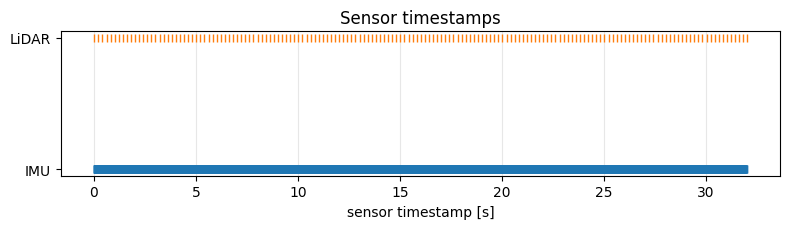

In [32]:
fig, ax = plt.subplots(figsize=(8, 2.4))
ax.plot(ds.imu.sensor_timestamps, np.zeros_like(ds.imu.sensor_timestamps), "|", label="IMU")
ax.plot(ds.lidar.sensor_timestamps, np.ones_like(ds.lidar.sensor_timestamps), "|", label="LiDAR")
ax.set_yticks([0, 1], ["IMU", "LiDAR"])
ax.set_xlabel("sensor timestamp [s]")
ax.set_title("Sensor timestamps")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "timestamps.png", dpi=160)
plt.show()
plt.close(fig)

## 5. Simulated Gyroscope And Accelerometer Streams

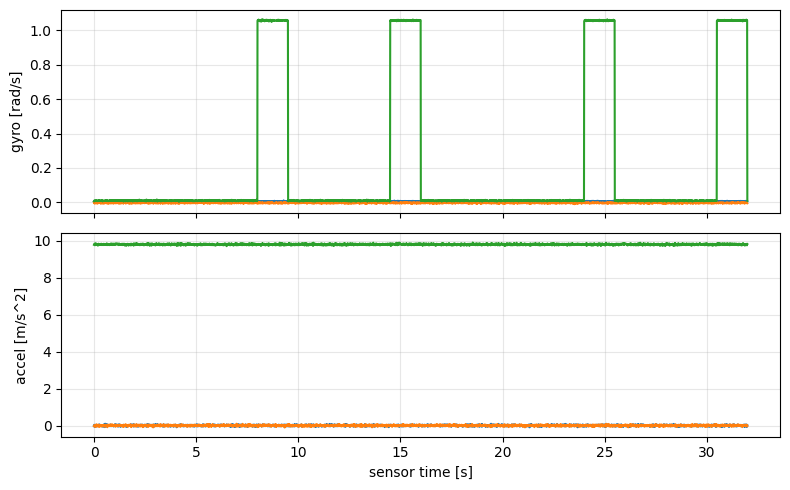

In [33]:
fig, axs = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
axs[0].plot(ds.imu.sensor_timestamps, ds.imu.gyroscope); axs[0].set_ylabel("gyro [rad/s]")
axs[1].plot(ds.imu.sensor_timestamps, ds.imu.accelerometer); axs[1].set_ylabel("accel [m/s^2]")
axs[1].set_xlabel("sensor time [s]")
for ax in axs:
    ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "imu_streams.png", dpi=160)
plt.show()
plt.close(fig)

## 6. Simulated LiDAR Relative-Pose Measurements

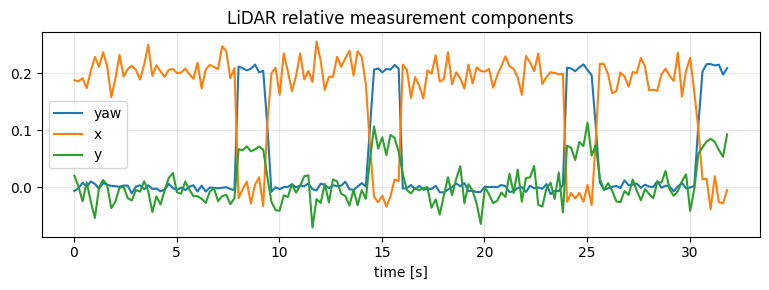

In [34]:
z_xi = np.vstack([se3_log(Z) for Z in ds.lidar.measurements])
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(ds.lidar.relative_start_times, z_xi[:, 2], label="yaw")
ax.plot(ds.lidar.relative_start_times, z_xi[:, 3], label="x")
ax.plot(ds.lidar.relative_start_times, z_xi[:, 4], label="y")
ax.set_xlabel("time [s]")
ax.set_title("LiDAR relative measurement components")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "lidar_measurements.png", dpi=160)
plt.show()
plt.close(fig)

## 7. True Extrinsic And Temporal-Offset Values

In [35]:
print("tau_I_true", ds.tau_I_true)
print("tau_L_true", ds.tau_L_true)
print("gyro_bias_true", ds.gyro_bias_true)
print("T_B_L_true tangent", se3_log(ds.T_B_L_true))
print("T_B_I_true tangent", se3_log(ds.T_B_I_true))

tau_I_true 0.01
tau_L_true -0.02
gyro_bias_true [ 0.005 -0.003  0.01 ]
T_B_L_true tangent [0.   0.   0.04 0.35 0.05 0.12]
T_B_I_true tangent [ 1.00000000e-02 -2.00000000e-02  3.00000000e-02  1.20000000e-01
 -3.01950305e-17  8.00000000e-02]


## 8. Dummy Pose-Provider Demonstration

In [36]:
provider = estimate_poses_dummy(ds)
poses = provider.poses_at(np.array([ds.start_time, ds.start_time + 1.0]))
assert poses.shape == (2, 4, 4)

## 9. One-Window Jacobian Layout And Sparsity Plot

In [37]:
w0, w1 = ds.start_time, min(ds.start_time + 10.0, ds.end_time)
bd, motions, counts = ds.window_jacobians(w0, w1, provider, use_sparse=False, jacobian_options=JACOBIAN_OPTIONS)
bs, _, _ = ds.window_jacobians(w0, w1, provider, use_sparse=True, jacobian_options=JACOBIAN_OPTIONS)
assert bd.J.shape == bs.J.shape
save_sparsity_plot(bs.J, OUT / "one_window_sparsity.png", "One-window sparse Jacobian")
print({"shape": bd.J.shape, "J_T": bd.J_T.shape, "J_C": bd.J_C.shape, "counts": counts})
print({
    "jacobian_method": bd.metadata.get("jacobian_method"),
    "all_checks_passed": bd.metadata.get("all_jacobian_checks_passed"),
    "max_check_error": bd.metadata.get("maximum_jacobian_check_error"),
})


{'shape': (441, 317), 'J_T': (441, 300), 'J_C': (441, 17), 'counts': {'imu': 49, 'lidar': 49}}
{'jacobian_method': 'analytic', 'all_checks_passed': True, 'max_check_error': 0.0}


## 10. Dense Versus Sparse Observability Comparison

In [38]:
O_dense = effective_observability_dense(bd.J_T, bd.J_C)
# print(bd.J_T)
# print(bd.J_C)
S_dense = O_dense.T @ O_dense
sparse_result = effective_observability_sparse_lsmr(bs.J_T, bs.J_C)
assert np.allclose(S_dense, sparse_result.S_C, atol=1e-7)
print({"rank_O_dense": rank_dense(O_dense), "rank_O_sparse": rank_dense(sparse_result.O_C), "nnz": sparse_result.nnz})

{'rank_O_dense': 7, 'rank_O_sparse': 7, 'nnz': 5733}


## 11. Sliding-Window Observability Over The Whole Trajectory

In [39]:
window_duration = 3.0
window_step = 3.0
relative_rank_threshold = 1e-5
results = analyze_observability_over_time(ds, provider, window_duration=window_duration, window_step=window_step, include_priors=False, use_sparse=True, rank_tolerance=1e-7, jacobian_options=JACOBIAN_OPTIONS)
assert len(results) >= 3
centers = np.array([(r["window_start"] + r["window_end"]) / 2 for r in results])
rank_JC = np.array([r["rank_J_C"] for r in results])
rank_CX = np.array([r["rank_C_X"] for r in results])
rank_OC = np.array([r["rank_O_C"] for r in results])
smin = np.array([r["smallest_nonzero_singular_value"] for r in results])
cond = np.array([r["condition_number"] for r in results])

factor_results = sliding_window_factor_diagnostics(
    ds,
    provider,
    window_duration=window_duration,
    step=window_step,
    relative_rank_threshold=relative_rank_threshold,
    normalization="physical_then_column",
    use_sparse=False,
    jacobian_options=JACOBIAN_OPTIONS,
)
assert len(factor_results) == len(results)


## 12. Plot Ranks, Smallest Singular Value, Condition Number, And Selected Standard Deviations

The first condition-number plot in this section uses `cond = r["condition_number"]` from `analyze_observability_over_time`. This is the condition number of the full projected calibration matrix `O_C = P_T_perp J_C` in each window. It uses all active calibration columns together and the old numerical-rank tolerance. Since `J_C` mixes rotations, translations, gyro bias, and time offsets, this value is strongly affected by physical units and raw column magnitudes.

The later individual condition-number plot uses `item.target_results[variable_name].effective_condition_number`. For each calibration variable, it first forms a target matrix `J_X`, lets trajectory poses and the other calibration variables act as nuisance columns `J_N`, and plots the condition number of `O_X = (I - P_N) J_X` after the diagnostic normalization mode `physical_then_column`. This means the plotted value describes the shape of the remaining per-variable observable subspace after nuisance compensation, not the conditioning of the full calibration problem.

So the two curves answer different questions. `cond` asks: how ill-conditioned is the whole joint calibration subspace in raw/scaled coordinates? The individual value asks: after all other variables compensate, how well conditioned is the retained observable part of this one variable under column-normalized diagnostics? A difference of many orders of magnitude, even around `1e8`, is therefore expected and usually reflects unit scaling, zero or nearly-zero directions, nuisance projection, and the fact that the effective condition number ignores singular values below `relative_rank_threshold`.


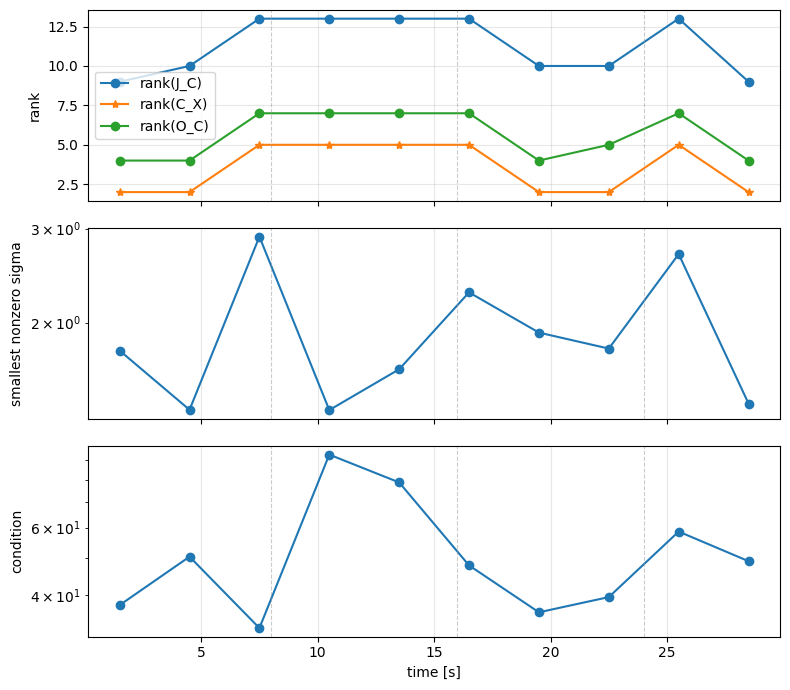

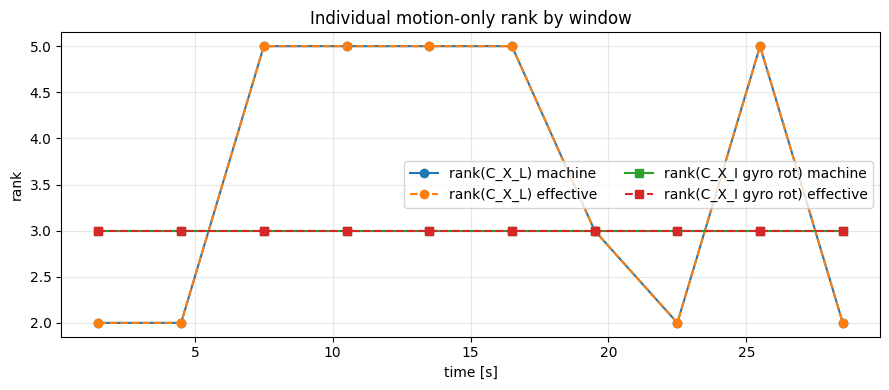

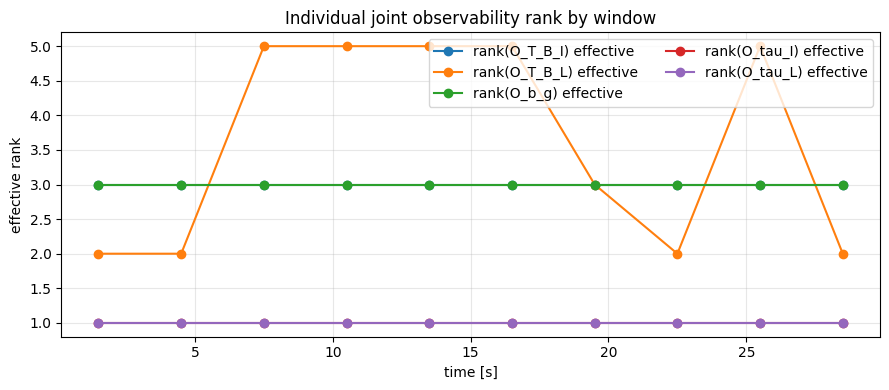

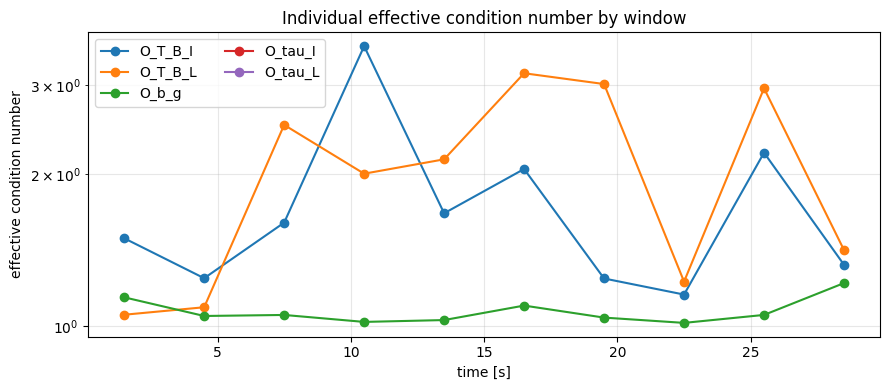

In [40]:
fig, axs = plt.subplots(3, 1, figsize=(8, 7), sharex=True)
axs[0].plot(centers, rank_JC, marker="o", label="rank(J_C)")
axs[0].plot(centers, rank_CX, marker="*", label="rank(C_X)")
axs[0].plot(centers, rank_OC, marker="o", label="rank(O_C)")
axs[0].legend(); axs[0].set_ylabel("rank")
axs[1].semilogy(centers, np.maximum(smin, 1e-16), marker="o"); axs[1].set_ylabel("smallest nonzero sigma")
axs[2].semilogy(centers, np.maximum(cond, 1.0), marker="o"); axs[2].set_ylabel("condition"); axs[2].set_xlabel("time [s]")
for ax in axs:
    for q in np.linspace(ds.start_time, ds.end_time, 5)[1:-1]:
        ax.axvline(q, color="0.6", lw=0.8, ls="--", alpha=0.5)
    ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "sliding_window_observability.png", dpi=160)
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(9, 4))
lidar_machine = [item.motion_lidar.machine_rank if item.motion_lidar else np.nan for item in factor_results]
lidar_effective = [item.motion_lidar.effective_rank if item.motion_lidar else np.nan for item in factor_results]
imu_machine = [item.motion_imu.rotation_machine_rank if item.motion_imu else np.nan for item in factor_results]
imu_effective = [item.motion_imu.rotation_effective_rank if item.motion_imu else np.nan for item in factor_results]
ax.plot(centers, lidar_machine, marker="o", label="rank(C_X_L) machine")
ax.plot(centers, lidar_effective, marker="o", linestyle="--", label="rank(C_X_L) effective")
ax.plot(centers, imu_machine, marker="s", label="rank(C_X_I gyro rot) machine")
ax.plot(centers, imu_effective, marker="s", linestyle="--", label="rank(C_X_I gyro rot) effective")
ax.set_xlabel("time [s]")
ax.set_ylabel("rank")
ax.set_title("Individual motion-only rank by window")
ax.grid(alpha=0.3)
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(OUT / "sliding_individual_motion_only_ranks.png", dpi=160)
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(9, 4))
for variable_name in SUPPORTED_CALIBRATION_VARIABLES:
    values = [item.target_results[variable_name].effective_rank_O_X if variable_name in item.target_results else np.nan for item in factor_results]
    ax.plot(centers, values, marker="o", label=f"rank(O_{variable_name}) effective")
ax.set_xlabel("time [s]")
ax.set_ylabel("effective rank")
ax.set_title("Individual joint observability rank by window")
ax.grid(alpha=0.3)
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(OUT / "sliding_individual_observability_ranks.png", dpi=160)
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(9, 4))
for variable_name in SUPPORTED_CALIBRATION_VARIABLES:
    values = [item.target_results[variable_name].effective_condition_number if variable_name in item.target_results else np.nan for item in factor_results]
    ax.semilogy(centers, values, marker="o", label=f"O_{variable_name}")
ax.set_xlabel("time [s]")
ax.set_ylabel("effective condition number")
ax.set_title("Individual effective condition number by window")
ax.grid(True, which="both", alpha=0.3)
ax.legend(ncol=2)
fig.tight_layout()
fig.savefig(OUT / "sliding_individual_condition_numbers.png", dpi=160)
plt.show()
plt.close(fig)


## 13. Straight Segments And Turns Marked On Plots

In [41]:
# The dashed quartile markers in the previous figure approximate the four sides/turn regions
# of the smooth rectangular trajectory. They are visual guides, not observability inputs.
assert (OUT / "sliding_window_observability.png").exists()

## 14. Compare Motion Modes

In [42]:
modes = ["stationary", "straight_constant_velocity", "straight_accelerating", "single_turn", "one_rectangle", "multiple_rectangles"]
mode_rows = []
for mode in modes:
    dsm = simulate_planar_rover(cfg, mode=mode)
    ppm = estimate_poses_dummy(dsm)
    bm, motions_m, _ = dsm.window_jacobians(dsm.start_time, dsm.end_time, ppm, use_sparse=False, jacobian_options=JACOBIAN_OPTIONS)
    Cxm = build_motion_only_matrix_dense(motions_m)
    Om = effective_observability_dense(bm.J_T, bm.J_C) if bm.J.shape[0] else np.zeros((0, bm.J_C.shape[1]))
    mode_rows.append((mode, rank_dense(Cxm), rank_dense(bm.J_C), rank_dense(Om), bm.J.shape))
for row in mode_rows:
    print(row)
assert dict((m, c) for m, c, _, _, _ in mode_rows)["stationary"] == 0

('stationary', 0, 7, 4, (342, 251))
('straight_constant_velocity', 2, 10, 4, (342, 251))
('straight_accelerating', 2, 10, 4, (360, 263))
('single_turn', 4, 12, 7, (54, 59))
('one_rectangle', 5, 13, 7, (1422, 971))
('multiple_rectangles', 5, 13, 7, (2862, 1931))


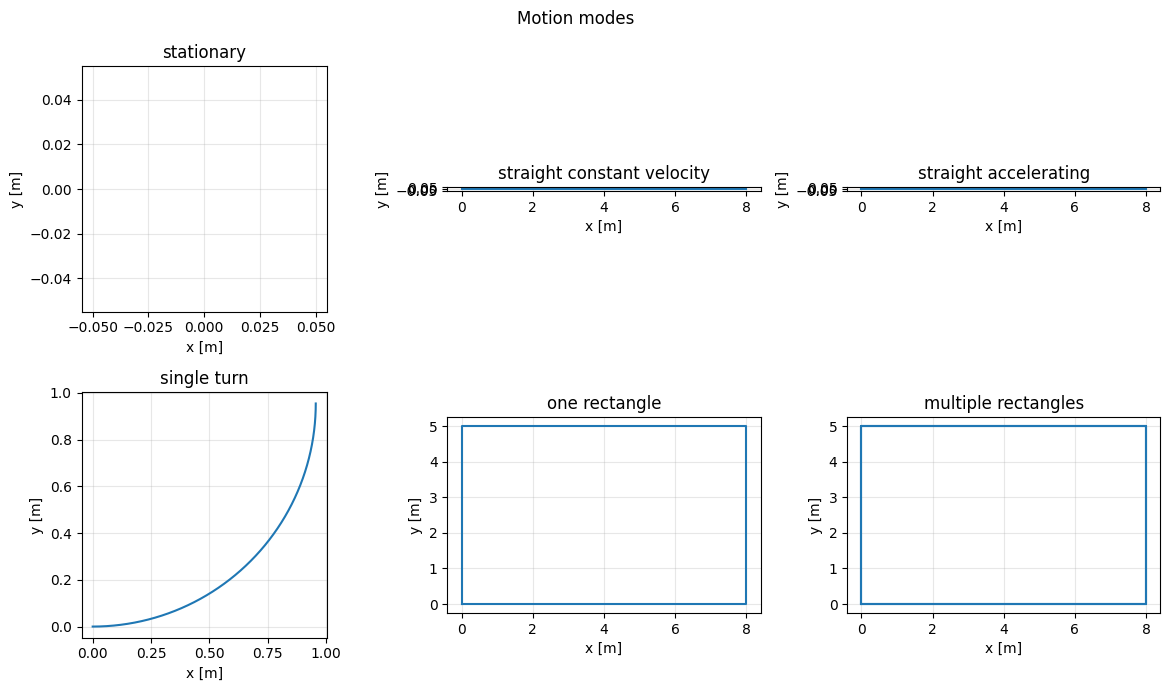

In [43]:
# 14A. Visual comparison of motion modes

comparison_modes = [
    "stationary",
    "straight_constant_velocity",
    "straight_accelerating",
    "single_turn",
    "one_rectangle",
    "multiple_rectangles",
]

RANK_TOL = 1e-7
mode_results = []

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.ravel()

for axis, mode in zip(axes, comparison_modes):
    dataset_mode = simulate_planar_rover(cfg, mode=mode)
    provider_mode = estimate_poses_dummy(dataset_mode)

    times_mode, xyz_mode, _ = dataset_mode.trajectory.sample(400)
    axis.plot(xyz_mode[:, 0], xyz_mode[:, 1])
    axis.set_aspect("equal", adjustable="box")
    axis.set_title(mode.replace("_", " "))
    axis.set_xlabel("x [m]")
    axis.set_ylabel("y [m]")
    axis.grid(alpha=0.3)

    bundle_mode, motions_mode, counts_mode = dataset_mode.window_jacobians(
        dataset_mode.start_time,
        dataset_mode.end_time,
        provider_mode,
        include_priors=False,
        use_sparse=False,
        jacobian_options=JACOBIAN_OPTIONS,
    )

    J_C_mode = np.asarray(bundle_mode.J_C)
    n_C_mode = J_C_mode.shape[1]

    if bundle_mode.J.shape[0] > 0:
        O_C_mode = np.asarray(
            effective_observability_dense(
                bundle_mode.J_T,
                bundle_mode.J_C,
            )
        )
    else:
        O_C_mode = np.zeros((0, n_C_mode), dtype=float)

    if motions_mode:
        C_X_mode = build_motion_only_matrix_dense(motions_mode)
    else:
        C_X_mode = np.zeros((0, 6), dtype=float)

    rank_J_C_mode = rank_dense(J_C_mode, tol=RANK_TOL)
    rank_O_C_mode = rank_dense(O_C_mode, tol=RANK_TOL)
    rank_C_X_mode = rank_dense(C_X_mode, tol=RANK_TOL)

    singular_values_mode = (
        np.linalg.svd(O_C_mode, compute_uv=False)
        if O_C_mode.size
        else np.zeros(0, dtype=float)
    )

    retained = singular_values_mode[
        singular_values_mode > RANK_TOL
    ]

    smallest_retained = (
        float(retained[-1])
        if retained.size
        else np.nan
    )

    # This condition number is computed only over singular values retained
    # by the chosen rank tolerance. It is not the full condition number of
    # a rank-deficient matrix, which would be infinite.
    effective_condition = (
        float(retained[0] / retained[-1])
        if retained.size >= 2
        else np.nan
    )

    mode_results.append(
        {
            "mode": mode,
            "rank_J_C": rank_J_C_mode,
            "rank_O_C": rank_O_C_mode,
            "rank_C_X": rank_C_X_mode,
            "n_C": n_C_mode,
            "n_X": C_X_mode.shape[1] if C_X_mode.ndim == 2 else 6,
            "singular_values_O_C": singular_values_mode,
            "smallest_retained_sigma": smallest_retained,
            "effective_condition": effective_condition,
            "imu_count": counts_mode["imu"],
            "lidar_count": counts_mode["lidar"],
        }
    )

fig.suptitle("Motion modes")
fig.tight_layout()
fig.savefig(OUT / "motion_mode_trajectories.png", dpi=160)
plt.show()
plt.close(fig)


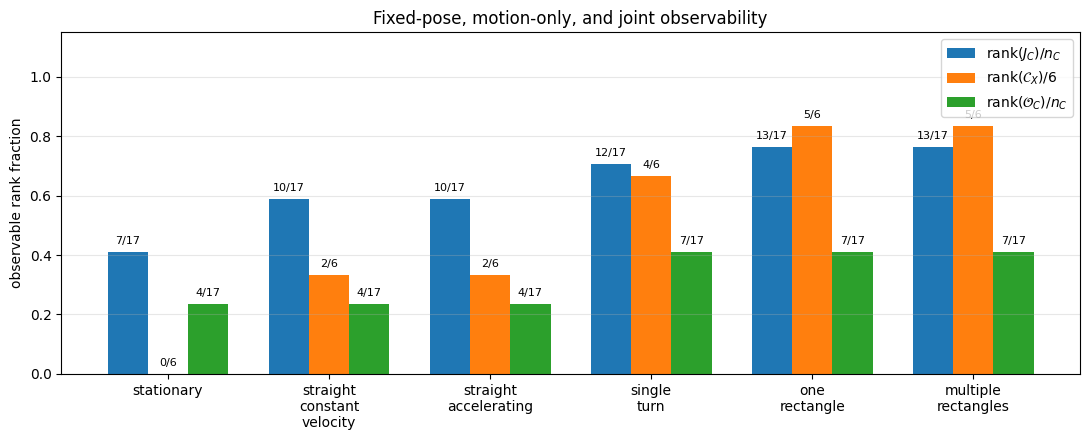

In [44]:
# Compare normalized ranks because C_X has 6 columns, while J_C and O_C
# contain the complete calibration vector.
mode_names = [result["mode"].replace("_", "\n") for result in mode_results]
x_positions = np.arange(len(mode_results))
bar_width = 0.25

rank_fraction_J_C = np.array(
    [
        result["rank_J_C"] / result["n_C"]
        if result["n_C"] else 0.0
        for result in mode_results
    ]
)
rank_fraction_O_C = np.array(
    [
        result["rank_O_C"] / result["n_C"]
        if result["n_C"] else 0.0
        for result in mode_results
    ]
)
rank_fraction_C_X = np.array(
    [
        result["rank_C_X"] / result["n_X"]
        if result["n_X"] else 0.0
        for result in mode_results
    ]
)

fig, ax = plt.subplots(figsize=(11, 4.5))

bars_J_C = ax.bar(
    x_positions - bar_width,
    rank_fraction_J_C,
    width=bar_width,
    label=r"$\mathrm{rank}(J_C)/n_C$",
)
bars_C_X = ax.bar(
    x_positions,
    rank_fraction_C_X,
    width=bar_width,
    label=r"$\mathrm{rank}(\mathcal{C}_X)/6$",
)
bars_O_C = ax.bar(
    x_positions + bar_width,
    rank_fraction_O_C,
    width=bar_width,
    label=r"$\mathrm{rank}(\mathcal{O}_C)/n_C$",
)

for bars, key, denominator_key in (
    (bars_J_C, "rank_J_C", "n_C"),
    (bars_C_X, "rank_C_X", "n_X"),
    (bars_O_C, "rank_O_C", "n_C"),
):
    for bar, result in zip(bars, mode_results):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f'{result[key]}/{result[denominator_key]}',
            ha="center",
            va="bottom",
            fontsize=8,
        )

ax.set_xticks(x_positions, mode_names)
ax.set_ylim(0.0, 1.15)
ax.set_ylabel("observable rank fraction")
ax.set_title("Fixed-pose, motion-only, and joint observability")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(OUT / "motion_mode_rank_comparison.png", dpi=160)
plt.show()
plt.close(fig)

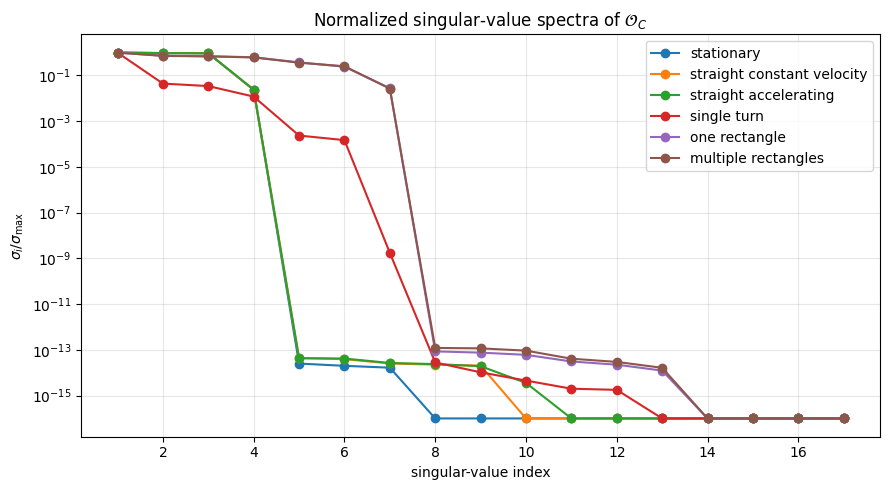

In [45]:
# Compare normalized singular-value spectra of O_C.
# Normalization shows the shape of each spectrum, not absolute information.
fig, ax = plt.subplots(figsize=(9, 5))

for result in mode_results:
    singular_values = result["singular_values_O_C"]
    if singular_values.size == 0 or singular_values[0] == 0.0:
        continue

    normalized_singular_values = singular_values / singular_values[0]

    ax.semilogy(
        np.arange(1, normalized_singular_values.size + 1),
        np.maximum(normalized_singular_values, 1e-16),
        marker="o",
        label=result["mode"].replace("_", " "),
    )

ax.set_xlabel("singular-value index")
ax.set_ylabel(r"$\sigma_i / \sigma_{\max}$")
ax.set_title(r"Normalized singular-value spectra of $\mathcal{O}_C$")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(OUT / "motion_mode_singular_spectra.png", dpi=160)
plt.show()
plt.close(fig)

In [46]:

# Print a compact numerical summary.
for result in mode_results:
    print(
        {
            "mode": result["mode"],
            "rank_J_C": f'{result["rank_J_C"]}/{result["n_C"]}',
            "rank_C_X": f'{result["rank_C_X"]}/{result["n_X"]}',
            "rank_O_C": f'{result["rank_O_C"]}/{result["n_C"]}',
            "smallest_retained_sigma": result["smallest_retained_sigma"],
            "effective_condition": result["effective_condition"],
            "imu": result["imu_count"],
            "lidar": result["lidar_count"],
        }
    )

{'mode': 'stationary', 'rank_J_C': '7/17', 'rank_C_X': '0/6', 'rank_O_C': '4/17', 'smallest_retained_sigma': 2.5899160600930857, 'effective_condition': 42.57761363220346, 'imu': 38, 'lidar': 38}
{'mode': 'straight_constant_velocity', 'rank_J_C': '10/17', 'rank_C_X': '2/6', 'rank_O_C': '4/17', 'smallest_retained_sigma': 2.5899160600930666, 'effective_condition': 42.57761363220326, 'imu': 38, 'lidar': 38}
{'mode': 'straight_accelerating', 'rank_J_C': '10/17', 'rank_C_X': '2/6', 'rank_O_C': '4/17', 'smallest_retained_sigma': 2.7172113359798002, 'effective_condition': 41.63722591907872, 'imu': 40, 'lidar': 40}
{'mode': 'single_turn', 'rank_J_C': '12/17', 'rank_C_X': '4/6', 'rank_O_C': '7/17', 'smallest_retained_sigma': 1.36364048759877e-07, 'effective_condition': 573108430.6412386, 'imu': 6, 'lidar': 6}
{'mode': 'one_rectangle', 'rank_J_C': '13/17', 'rank_C_X': '5/6', 'rank_O_C': '7/17', 'smallest_retained_sigma': 8.947958532962515, 'effective_condition': 35.96167208817711, 'imu': 158, 'li

## 15. Measurement-Only Observability Versus Regularized Uncertainty

In [47]:
b_meas, _, _ = ds.window_jacobians(w0, w1, provider, include_priors=False, use_sparse=False, jacobian_options=JACOBIAN_OPTIONS)
b_reg, _, _ = ds.window_jacobians(w0, w1, provider, include_priors=True, include_smoothness=True, use_sparse=False, jacobian_options=JACOBIAN_OPTIONS)
O_meas = effective_observability_dense(b_meas.J_T, b_meas.J_C)
O_reg = effective_observability_dense(b_reg.J_T, b_reg.J_C)
print({"measurement_only_rank": rank_dense(O_meas), "regularized_rank": rank_dense(O_reg)})
assert rank_dense(O_reg) >= rank_dense(O_meas)
print("Priors can make a regularized matrix full rank without proving measurement-based observability.")

/tmp/ipykernel_3168182/2991810319.py:2: RuntimeWarning: Spatial smoothness requires multiple time-indexed extrinsic nodes. This dataset currently has one constant T_B_I and one constant T_B_L, so no smoothness factor is added. A one-node smoothness term would be a prior and would misrepresent measurement observability.
  b_reg, _, _ = ds.window_jacobians(w0, w1, provider, include_priors=True, include_smoothness=True, use_sparse=False, jacobian_options=JACOBIAN_OPTIONS)


{'measurement_only_rank': 7, 'regularized_rank': 17}
Priors can make a regularized matrix full rank without proving measurement-based observability.


## 16. SE(3)-Embedded Planar Versus Reduced SE(2) Versus Synthetic 3D

In [48]:
Cx_planar = build_motion_only_matrix_dense(motions)
rank_planar = rank_dense(Cx_planar)
As2 = [
    se2_exp(np.array([0.0, 1.0, 0.0])),
    se2_exp(np.array([np.pi / 2, 1.0, 0.5])),
    se2_exp(np.array([-np.pi / 3, 0.5, 0.8])),
]
rank_se2 = rank_dense(build_motion_only_matrix_dense_se2(As2), tol=1e-9)
ds3 = simulate_planar_rover(cfg, mode="multi-axis_3d_reference_motion")
pp3 = estimate_poses_dummy(ds3)
b3, motions3, _ = ds3.window_jacobians(ds3.start_time, ds3.end_time, pp3, use_sparse=False, jacobian_options=JACOBIAN_OPTIONS)
rank_3d = rank_dense(build_motion_only_matrix_dense(motions3), tol=1e-7)
print({"SE3_planar_CX_rank": rank_planar, "SE2_reference_CX_rank": rank_se2, "synthetic_3D_CX_rank": rank_3d})
assert rank_planar < 6
assert rank_se2 == 3
assert rank_3d == 6

{'SE3_planar_CX_rank': 5, 'SE2_reference_CX_rank': 3, 'synthetic_3D_CX_rank': 6}


## 17. Weakest Calibration Right-Singular Vectors

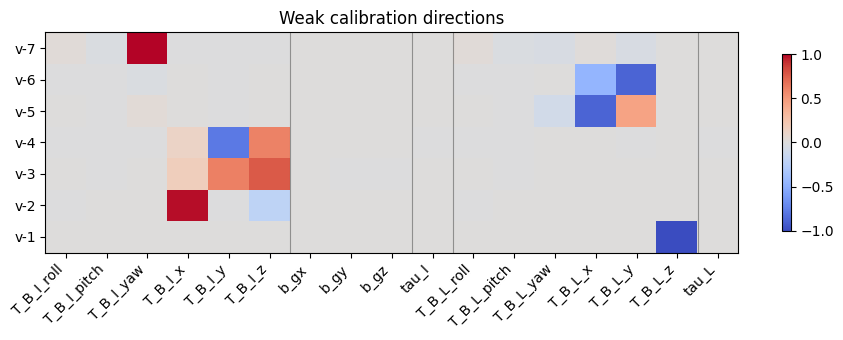

In [49]:
# Use the active calibration layout from the Jacobian bundle instead of hard-coded labels.
# Full IMU + LiDAR windows should give:
# T_B_I(6), b_g(3), tau_I(1), T_B_L(6), tau_L(1) = 17 calibration columns.
observability_matrix = O_dense.toarray() if sparse.issparse(O_dense) else np.asarray(O_dense)

calibration_labels = list(bd.metadata.get("calibration_labels", []))
if len(calibration_labels) != observability_matrix.shape[1]:
    calibration_labels = [f"c_{column_index}" for column_index in range(observability_matrix.shape[1])]

U, singular_values, Vt = np.linalg.svd(observability_matrix, full_matrices=False)
weak_mode_count = min(7, Vt.shape[0])
weakest_modes = Vt[-weak_mode_count:]

color_limit = float(np.max(np.abs(weakest_modes))) if weakest_modes.size else 1.0
color_limit = color_limit if color_limit > 0.0 else 1.0

fig_width = max(8.0, 0.55 * len(calibration_labels))
fig, ax = plt.subplots(figsize=(fig_width, 3.5))
image = ax.imshow(
    weakest_modes,
    aspect="auto",
    cmap="coolwarm",
    vmin=-color_limit,
    vmax=color_limit,
)

ax.set_xticks(range(len(calibration_labels)), calibration_labels, rotation=45, ha="right")
ax.set_yticks(
    range(weakest_modes.shape[0]),
    [f"v-{mode_index}" for mode_index in range(weak_mode_count, 0, -1)],
)
ax.set_title("Weak calibration directions")

# Draw separators between calibration blocks such as T_B_I, b_g, tau_I, T_B_L, tau_L.
calibration_blocks = bd.metadata.get("calibration_blocks", [])
block_end_column = 0
for block_name, block_dimension in calibration_blocks[:-1]:
    block_end_column += block_dimension
    ax.axvline(block_end_column - 0.5, color="black", linewidth=0.8, alpha=0.35)

fig.colorbar(image, ax=ax, shrink=0.8)
fig.tight_layout()
fig.savefig(OUT / "weak_singular_vectors.png", dpi=160)
plt.show()
plt.close(fig)



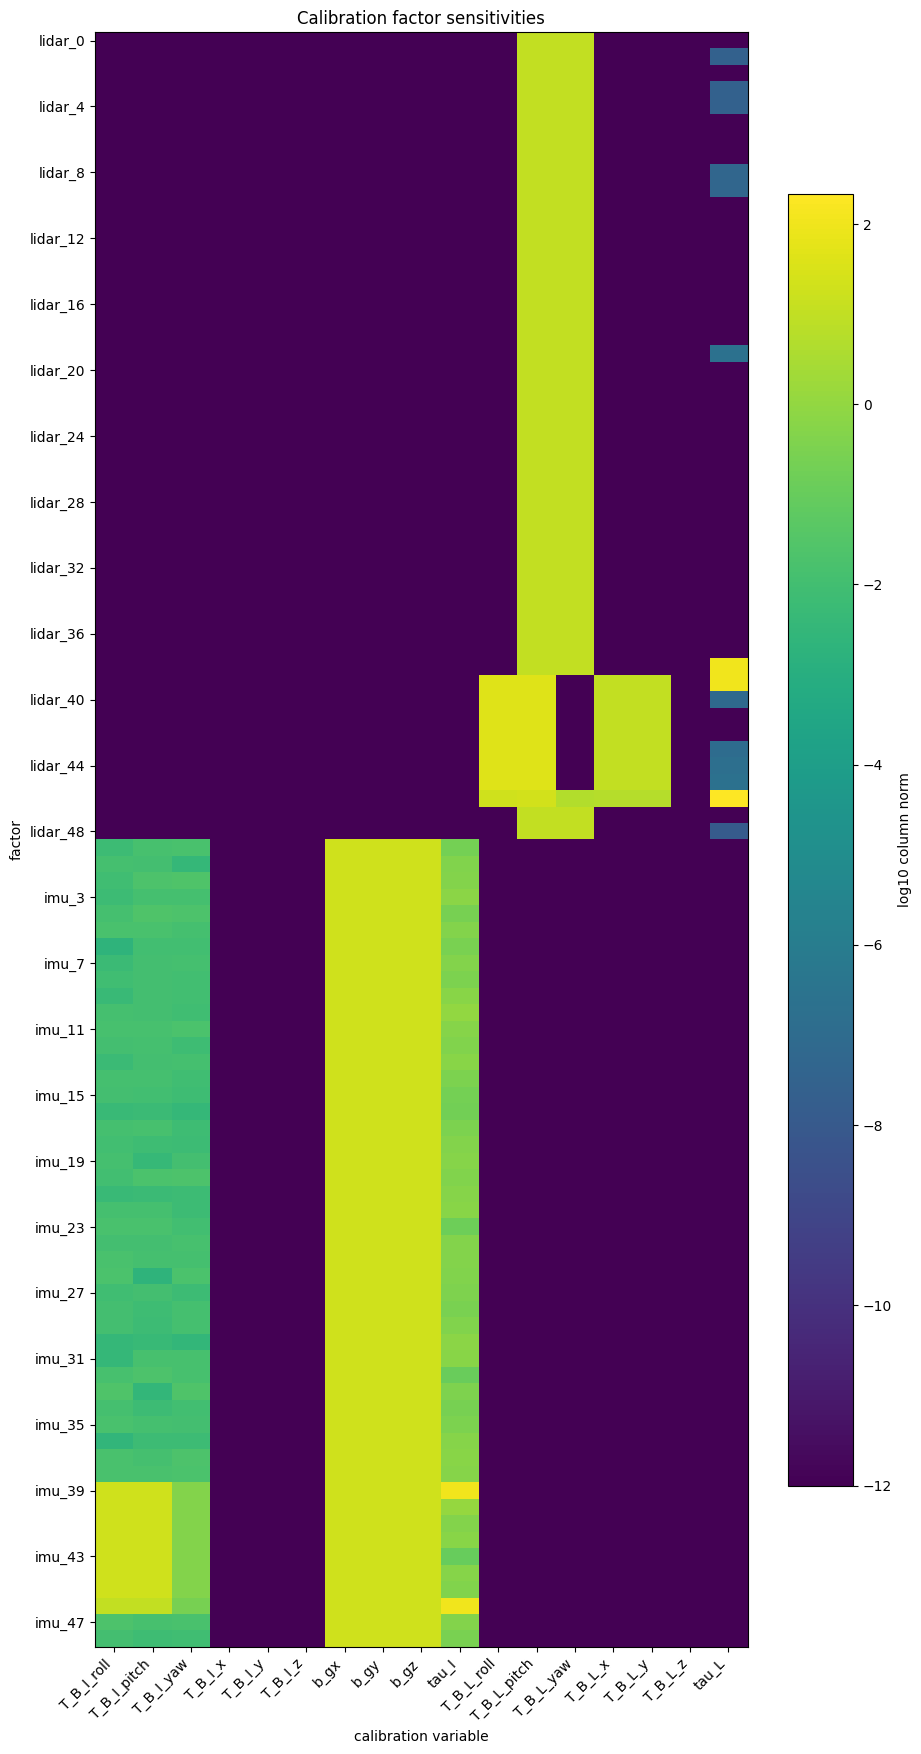

PosixPath('/home/camel/Skoltech/phd_proposal/outputs/planar_rover/one_window_singular_values.png')

In [50]:
# Plot which measurement/prior factors touch which calibration variables.
calibration_jacobian = bd.J_C.toarray() if sparse.issparse(bd.J_C) else np.asarray(bd.J_C)

factor_names = []
factor_column_norms = []
for factor_name, row_slice in bd.row_slices.items():
    factor_block = calibration_jacobian[row_slice, :]
    factor_names.append(factor_name)
    factor_column_norms.append(np.linalg.norm(factor_block, axis=0))

factor_column_norms = np.asarray(factor_column_norms)
log_factor_strength = np.log10(factor_column_norms + 1e-12)

fig_height = max(4.0, 0.18 * len(factor_names))
fig, ax = plt.subplots(figsize=(fig_width, fig_height))
image = ax.imshow(log_factor_strength, aspect="auto", cmap="viridis")

ax.set_xticks(range(len(calibration_labels)), calibration_labels, rotation=45, ha="right")

max_factor_ticks = 30
factor_tick_step = max(1, int(np.ceil(len(factor_names) / max_factor_ticks)))
factor_tick_indices = np.arange(0, len(factor_names), factor_tick_step)
ax.set_yticks(factor_tick_indices, [factor_names[index] for index in factor_tick_indices])

ax.set_title("Calibration factor sensitivities")
ax.set_xlabel("calibration variable")
ax.set_ylabel("factor")
fig.colorbar(image, ax=ax, shrink=0.8, label="log10 column norm")

fig.tight_layout()
fig.savefig(OUT / "calibration_factor_sensitivities.png", dpi=160)
plt.show()
plt.close(fig)

save_singular_values_plot(
    singular_values,
    OUT / "one_window_singular_values.png",
    "One-window O_C singular values",
)

## 18. Approximate Physical Interpretation

## 18. Physical Interpretation of the Weak Directions

For this particular ten-second window, the calibration vector contains 17
parameters, while the projected calibration observability matrix has rank 10.
Therefore, seven independent calibration combinations are unobservable at the
chosen numerical tolerance.

The displayed right-singular vectors indicate the following dominant weak
subspaces:

1. The three components of IMU translation are unobservable because the current
   IMU model uses only gyroscope propagation. A gyroscope-only factor is
   independent of the IMU lever-arm translation.

2. LiDAR vertical translation is unobservable under the planar motion. The
   bottom singular vector is almost a pure \(T_{B L,z}\) direction.

3. Additional weak directions contain coupled LiDAR planar translation and yaw
   components. These are not absent merely because of the motion-only
   sensitivity. They become weak after allowing the shared trajectory poses to
   compensate for calibration changes.

4. The SVD null-space basis is not unique. When several singular values are
   zero or nearly equal, the corresponding vectors may rotate within the same
   null subspace. Therefore the complete weak subspace is more meaningful than
   the exact appearance of one individual singular vector.

5. Singular-vector coefficients should be interpreted only after parameter
   scaling, because the calibration vector mixes radians, metres, bias units,
   and seconds.

Turns increase the number of observable calibration combinations compared with
straight motion, but some newly observable directions remain weak. This is
visible in the small retained singular values and large effective condition
numbers.

## 19. Matrix Sizes, Nonzero Counts, And Dense/Sparse Runtimes

In [51]:
t0 = time.perf_counter()
_ = effective_observability_dense(bd.J_T, bd.J_C)
dense_runtime = time.perf_counter() - t0
t0 = time.perf_counter()
sp = effective_observability_sparse_lsmr(bs.J_T, bs.J_C)
sparse_runtime = time.perf_counter() - t0
print({"J_shape": bd.J.shape, "J_sparse_nnz": bs.J.nnz, "dense_runtime_s": dense_runtime, "sparse_runtime_s": sparse_runtime, "sparse_density": bs.J.nnz / (bs.J.shape[0] * bs.J.shape[1])})

{'J_shape': (441, 317), 'J_sparse_nnz': 5013, 'dense_runtime_s': 0.15401089400984347, 'sparse_runtime_s': 2.3663448840379715, 'sparse_density': 0.03585913860812464}


## 20. Figures Saved Under `outputs/planar_rover/`

In [52]:
saved = sorted(p.name for p in OUT.glob("*.png"))
print(saved)
expected_figures = {
    "trajectory_xy.png",
    "sliding_window_observability.png",
    "weak_singular_vectors.png",
    "sliding_individual_motion_only_ranks.png",
    "sliding_individual_observability_ranks.png",
    "sliding_individual_condition_numbers.png",
}
assert expected_figures.issubset(saved)


['calibration_factor_sensitivities.png', 'imu_streams.png', 'lidar_measurements.png', 'motion_mode_rank_comparison.png', 'motion_mode_singular_spectra.png', 'motion_mode_trajectories.png', 'one_window_singular_values.png', 'one_window_sparsity.png', 'sliding_individual_condition_numbers.png', 'sliding_individual_motion_only_ranks.png', 'sliding_individual_observability_ranks.png', 'sliding_window_observability.png', 'timestamps.png', 'trajectory_timeseries.png', 'trajectory_xy.png', 'weak_singular_vectors.png']
